# Kriging Interpolation and Score Uncertainty

This notebook demonstrates three interpolation methods available in TerraFlow v0.2.1:

- **`linear`** — `scipy.griddata` triangular interpolation (default, fast)
- **`kriging`** — Ordinary Kriging via `pykrige`; adds per-cell `{var}_krig_std` uncertainty columns
- **`idw`** — Inverse Distance Weighting (power=2); fast, no uncertainty output

It also shows how to use `uncertainty_samples` to propagate kriging uncertainty through the
suitability model and obtain per-cell score confidence intervals (`score_ci_low` / `score_ci_high`).

**Study area:** Manhattan, Kansas (39.18°N, 97.48°W)

## 0. Dependencies

In [1]:
import io
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.crs import CRS
from rasterio.transform import from_bounds

import terraflow
from terraflow.pipeline import run_pipeline

print(f"TerraFlow {terraflow.__version__}")

TerraFlow 0.2.1


## 1. Synthetic data

Generate a small GeoTIFF and a climate CSV with 8 synthetic weather stations.

In [2]:
TMPDIR = pathlib.Path(tempfile.mkdtemp(prefix="terraflow_kriging_"))

# ── Raster ──────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
raster_path = TMPDIR / "land_cover.tif"

# 60x60 pixel raster centred on Manhattan, KS
xmin, ymin, xmax, ymax = -97.60, 39.10, -97.36, 39.26
H, W = 60, 60
data = rng.uniform(0.1, 0.9, (1, H, W)).astype("float32")

with rasterio.open(
    raster_path, "w",
    driver="GTiff", height=H, width=W, count=1,
    dtype="float32", crs=CRS.from_epsg(4326),
    transform=from_bounds(xmin, ymin, xmax, ymax, W, H),
) as dst:
    dst.write(data)

# ── Climate CSV ──────────────────────────────────────────────────────────────
# 8 stations with a north-south temperature gradient and east-west rainfall gradient
station_lats = np.array([39.11, 39.14, 39.17, 39.20, 39.23, 39.12, 39.18, 39.24])
station_lons = np.array([-97.57, -97.50, -97.43, -97.57, -97.50, -97.43, -97.55, -97.45])
mean_temp  = 28.0 - 4.0 * (station_lats - station_lats.min()) + rng.normal(0, 0.4, 8)
total_rain = 420 + 80  * (station_lons  - station_lons.min())  + rng.normal(0, 15,  8)

climate_path = TMPDIR / "climate.csv"
climate_df = pd.DataFrame({
    "lat": station_lats, "lon": station_lons,
    "mean_temp": mean_temp, "total_rain": total_rain,
})
climate_df.to_csv(climate_path, index=False)

print("Raster:", raster_path)
print("Climate stations:")
print(climate_df.to_string(index=False))

Raster: /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/land_cover.tif
Climate stations:
  lat    lon  mean_temp  total_rain
39.11 -97.57  28.178584  406.193164
39.14 -97.50  27.855963  449.123097
39.17 -97.43  27.765031  436.970850
39.20 -97.57  27.902727  400.146175
39.23 -97.50  27.229053  402.494684
39.12 -97.43  27.976135  429.517541
39.18 -97.55  27.595093  445.017798
39.24 -97.45  26.845759  426.798628


## 2. Shared config builder

In [3]:
import yaml

BASE = dict(
    raster_path=str(raster_path),
    climate_csv=str(climate_path),
    roi=dict(type="bbox", xmin=-97.58, ymin=39.11, xmax=-97.38, ymax=39.25),
    model_params=dict(
        v_min=0.2, v_max=0.8,
        t_min=20.0, t_max=32.0,
        r_min=350.0, r_max=550.0,
        w_v=0.35, w_t=0.35, w_r=0.30,
    ),
    max_cells=200,
)

def write_config(name: str, climate_block: dict, **extra) -> pathlib.Path:
    cfg = {**BASE, "output_dir": str(TMPDIR / name), "climate": climate_block, **extra}
    p = TMPDIR / f"{name}.yml"
    p.write_text(yaml.dump(cfg))
    return p

## 3. Run all three interpolation methods

In [4]:
cfg_linear  = write_config("linear",  {"strategy": "spatial", "interpolation_method": "linear",  "fallback_to_mean": True})
cfg_idw     = write_config("idw",     {"strategy": "spatial", "interpolation_method": "idw",     "fallback_to_mean": True})
cfg_kriging = write_config("kriging", {"strategy": "spatial", "interpolation_method": "kriging", "fallback_to_mean": True})

df_linear  = run_pipeline(cfg_linear)
df_idw     = run_pipeline(cfg_idw)
df_kriging = run_pipeline(cfg_kriging)

print("Linear  columns:", list(df_linear.columns))
print("IDW     columns:", list(df_idw.columns))
print("Kriging columns:", list(df_kriging.columns))

INFO:terraflow:Loaded config from /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/linear.yml


INFO:terraflow:Computed run fingerprint 0bQ28DGzlJCoFHqllXMpYPjnADt8DUqUfxLIavbal5o (config=b8dfbd23cd252bdfb36f64826301ffbf158ab16418e33f538897125e88d8ea76, inputs=2)


INFO:terraflow:DataCatalog built: raster=land_cover.tif (CRS EPSG:4326, shape (60, 60)), climate=climate.csv (8 rows, vars=['mean_temp', 'total_rain'])


INFO:terraflow:Loaded raster from /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/land_cover.tif


INFO:terraflow:Loaded climate CSV from /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/climate.csv with 8 rows


...

INFO:terraflow:Sampled 200 cells from 2650 valid cells in ROI


INFO:terraflow:Interpolated climate for 200 cells using strategy='spatial'


INFO:terraflow:Closed raster dataset


INFO:terraflow:Artifacts written to /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/kriging/runs/irH9dPRnke3eIcfKQmt0QOCTwKSGGyaTvU7uETOH3SE (fingerprint=irH9dPRnke3eIcfKQmt0QOCTwKSGGyaTvU7uETOH3SE, cells=200, total=0.43s)


Linear  columns: ['run_id', 'cell_id', 'lat', 'lon', 'v_index', 'mean_temp', 'total_rain', 'score', 'label']
IDW     columns: ['run_id', 'cell_id', 'lat', 'lon', 'v_index', 'mean_temp', 'total_rain', 'score', 'label']
Kriging columns: ['run_id', 'cell_id', 'lat', 'lon', 'v_index', 'mean_temp', 'total_rain', 'score', 'label', 'mean_temp_krig_std', 'total_rain_krig_std']


Kriging adds `mean_temp_krig_std` and `total_rain_krig_std` — the per-cell kriging standard deviation.
These reflect how uncertain the climate estimate is at each location given the station network.

## 4. Compare score distributions across methods

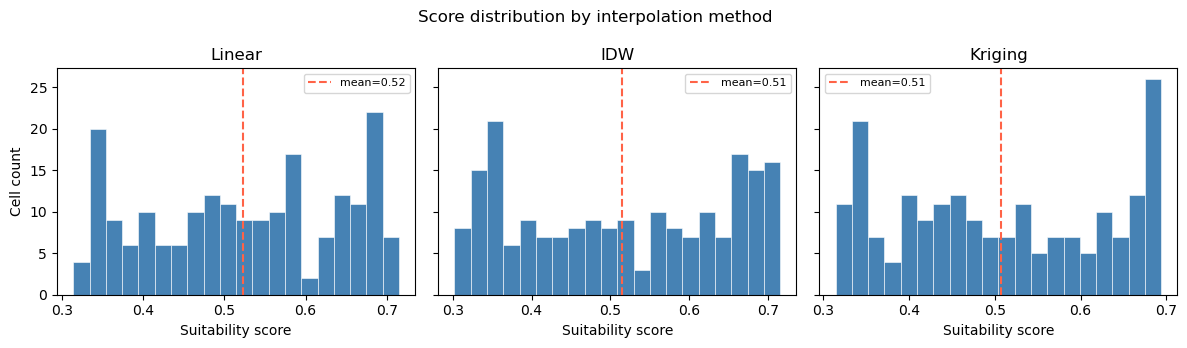

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, df, title in zip(
    axes,
    [df_linear, df_idw, df_kriging],
    ["Linear", "IDW", "Kriging"],
):
    ax.hist(df["score"], bins=20, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel("Suitability score")
    ax.axvline(df["score"].mean(), color="tomato", linewidth=1.5, linestyle="--", label=f"mean={df['score'].mean():.2f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Cell count")
fig.suptitle("Score distribution by interpolation method", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Kriging uncertainty: per-cell std dev

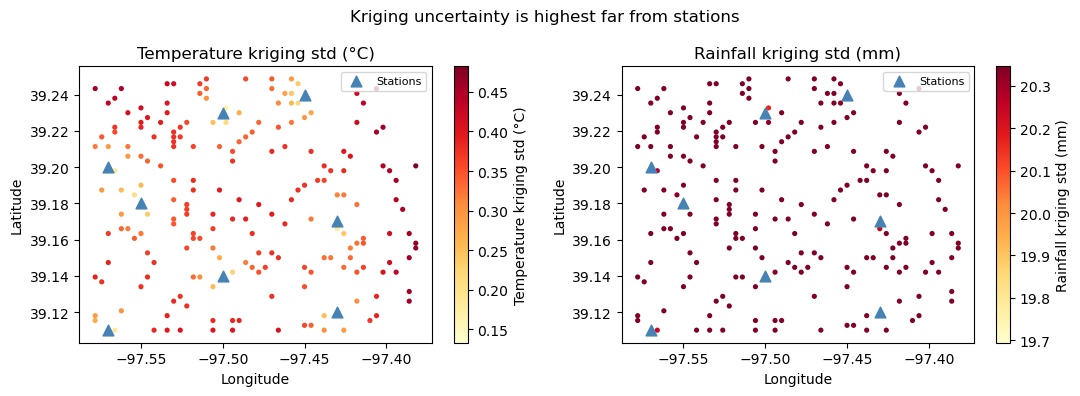

Temp std   — mean: 0.355°C  max: 0.482°C
Rain std   — mean: 20.3mm  max: 20.3mm


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, label in zip(
    axes,
    ["mean_temp_krig_std", "total_rain_krig_std"],
    ["Temperature kriging std (°C)", "Rainfall kriging std (mm)"],
):
    sc = ax.scatter(df_kriging["lon"], df_kriging["lat"],
                    c=df_kriging[col], cmap="YlOrRd", s=14, linewidths=0)
    plt.colorbar(sc, ax=ax, label=label)
    # Mark station locations
    ax.scatter(station_lons, station_lats, marker="^", color="steelblue",
               s=60, zorder=5, label="Stations")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle("Kriging uncertainty is highest far from stations", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Temp std   — mean: {df_kriging['mean_temp_krig_std'].mean():.3f}°C  "
      f"max: {df_kriging['mean_temp_krig_std'].max():.3f}°C")
print(f"Rain std   — mean: {df_kriging['total_rain_krig_std'].mean():.1f}mm  "
      f"max: {df_kriging['total_rain_krig_std'].max():.1f}mm")

## 6. Monte Carlo score confidence intervals

Set `uncertainty_samples: 500` to propagate kriging std through the suitability model.
This adds `score_ci_low` (5th percentile) and `score_ci_high` (95th percentile) per cell.

In [7]:
cfg_mc = write_config(
    "kriging_mc",
    {"strategy": "spatial", "interpolation_method": "kriging", "fallback_to_mean": True},
    # Pass uncertainty_samples under model_params
)

# Reload config dict and add uncertainty_samples to model_params
import yaml
cfg_dict = yaml.safe_load(cfg_mc.read_text())
cfg_dict["model_params"]["uncertainty_samples"] = 500
cfg_mc.write_text(yaml.dump(cfg_dict))

df_mc = run_pipeline(cfg_mc)

print("Monte Carlo columns added:",
      [c for c in df_mc.columns if "ci" in c])
print(df_mc[["score", "score_ci_low", "score_ci_high"]].describe().round(3))

INFO:terraflow:Loaded config from /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/kriging_mc.yml


INFO:terraflow:Computed run fingerprint nQHHejyvY-YHcd50k8WqiYXkxSADC3acUEuL08IEfAA (config=3b056479d5af3578cfecb0e5e520910cc8d212c461429975c90b6488e2c57bd2, inputs=2)


INFO:terraflow:DataCatalog built: raster=land_cover.tif (CRS EPSG:4326, shape (60, 60)), climate=climate.csv (8 rows, vars=['mean_temp', 'total_rain'])


INFO:terraflow:Loaded raster from /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/land_cover.tif


INFO:terraflow:Loaded climate CSV from /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/climate.csv with 8 rows


...

INFO:terraflow:Interpolated climate for 200 cells using strategy='spatial'


INFO:terraflow:Monte Carlo uncertainty propagation complete: 500 samples per cell


INFO:terraflow:Closed raster dataset


INFO:terraflow:Artifacts written to /var/folders/h_/_bjpnb894kgf18frynwf6bww0000gn/T/terraflow_kriging_a8j2jgrw/kriging_mc/runs/nQHHejyvY-YHcd50k8WqiYXkxSADC3acUEuL08IEfAA (fingerprint=nQHHejyvY-YHcd50k8WqiYXkxSADC3acUEuL08IEfAA, cells=200, total=0.42s)


Monte Carlo columns added: ['score_ci_low', 'score_ci_high']
         score  score_ci_low  score_ci_high
count  200.000       200.000        200.000
mean     0.502         0.449          0.555
std      0.122         0.122          0.122
min      0.314         0.263          0.364
25%      0.399         0.345          0.452
50%      0.491         0.439          0.541
75%      0.606         0.557          0.660
max      0.697         0.645          0.752


## 7. Visualise score ± confidence interval

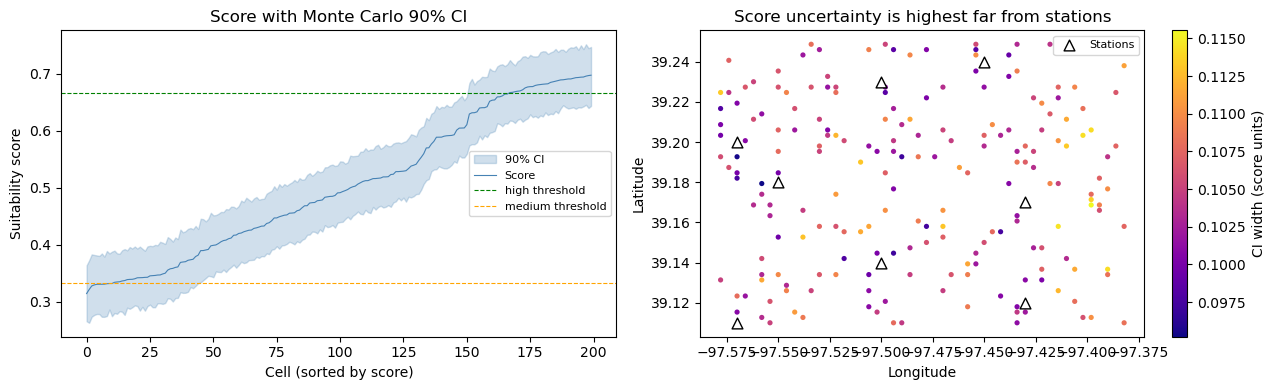

Mean CI width: 0.105  |  Max CI width: 0.116


In [8]:
df_sorted = df_mc.sort_values("score").reset_index(drop=True)
ci_width  = df_sorted["score_ci_high"] - df_sorted["score_ci_low"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: score with CI ribbon
ax = axes[0]
ax.fill_between(df_sorted.index, df_sorted["score_ci_low"], df_sorted["score_ci_high"],
                alpha=0.25, color="steelblue", label="90% CI")
ax.plot(df_sorted.index, df_sorted["score"], color="steelblue", linewidth=0.8, label="Score")
ax.axhline(2/3, color="green",  linewidth=0.8, linestyle="--", label="high threshold")
ax.axhline(1/3, color="orange", linewidth=0.8, linestyle="--", label="medium threshold")
ax.set_xlabel("Cell (sorted by score)")
ax.set_ylabel("Suitability score")
ax.set_title("Score with Monte Carlo 90% CI")
ax.legend(fontsize=8)

# Right: CI width mapped spatially
ax = axes[1]
sc = ax.scatter(df_mc["lon"], df_mc["lat"],
                c=(df_mc["score_ci_high"] - df_mc["score_ci_low"]),
                cmap="plasma", s=14, linewidths=0)
plt.colorbar(sc, ax=ax, label="CI width (score units)")
ax.scatter(station_lons, station_lats, marker="^", color="white",
           edgecolors="black", s=60, zorder=5, label="Stations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Score uncertainty is highest far from stations")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Mean CI width: {ci_width.mean():.3f}  |  Max CI width: {ci_width.max():.3f}")

## 8. Label stability analysis

Cells whose confidence interval crosses a threshold boundary (0.33 or 0.67) have ambiguous labels.
These are the locations where additional climate data collection would add most value.

Ambiguous labels (CI crosses a threshold): 94 / 200 cells (47.0%)


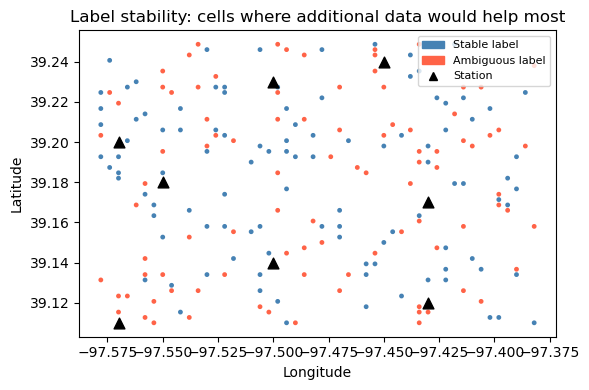

In [9]:
THRESHOLDS = [1/3, 2/3]

def ci_crosses(row):
    for t in THRESHOLDS:
        if row["score_ci_low"] < t < row["score_ci_high"]:
            return True
    return False

df_mc["label_ambiguous"] = df_mc.apply(ci_crosses, axis=1)

n_ambiguous = df_mc["label_ambiguous"].sum()
pct = 100 * n_ambiguous / len(df_mc)
print(f"Ambiguous labels (CI crosses a threshold): {n_ambiguous} / {len(df_mc)} cells ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
colors = df_mc["label_ambiguous"].map({True: "tomato", False: "steelblue"})
ax.scatter(df_mc["lon"], df_mc["lat"], c=colors, s=12, linewidths=0)
ax.scatter(station_lons, station_lats, marker="^", color="black", s=60, zorder=5, label="Stations")
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", label="Stable label"),
    Patch(color="tomato",    label="Ambiguous label"),
    plt.Line2D([0], [0], marker="^", color="black", linestyle="none", label="Station"),
], fontsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Label stability: cells where additional data would help most")
plt.tight_layout()
plt.show()

## Summary

| Method | Extra columns | Speed | Notes |
|---|---|---|---|
| `linear` | none | fast | good default for dense station networks |
| `idw` | none | fast | smoother gradients than linear |
| `kriging` | `{var}_krig_std` | slower | geostatistically optimal; enables uncertainty |
| `kriging` + `uncertainty_samples` | `score_ci_low`, `score_ci_high` | slowest | full MC uncertainty propagation |

The `score_ci_low` / `score_ci_high` columns identify locations where label assignments are
sensitive to climate estimation uncertainty — useful for prioritising field validation efforts.